In [1]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\2021-11-european-natural-gas-imports'

In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports'

In [3]:
os.chdir(Share_point)

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

import eurostat  # python wrapper for taking data.
import time

In [5]:
# Converter for metric tonnes to M3m 
# converter = -0.001397 WRONG
converter = -0.001379

### In Million tonnes

In [6]:
d1 = pd.read_excel('raw_data/LNG/Europe LNG 2017_2018.xlsx',index_col=1)
d2 = pd.read_excel('raw_data/LNG/Europe LNG 2019_2020.xlsx',index_col=1)
d3 = pd.read_excel('raw_data/LNG/Europe LNG 2021_2022.xlsx',index_col=1)
d4 = pd.read_excel('raw_data/LNG/Europe LNG 2023.xlsx',index_col=1)

In [7]:
# Merge 2017 to 2020
df_20 = pd.merge(d1,d2,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [8]:
# Merge 2017 to 2022
df_22 = pd.merge(df_20,d3,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [9]:
# Merge 2022 to 2023
df = pd.merge(df_22,d4,on=['Origin_Berthcountry','Port_Country'],how='outer')

In [10]:
not_EU_ES_PT = ['United Kingdom','Turkey','Spain','Portugal']
df_EU25 = df.loc[~df['Port_Country'].isin((not_EU_ES_PT))] 

### Single-out Spain and Portugal

In [11]:
iberia = df[df['Port_Country'].isin(['Spain','Portugal'])].reset_index()

In [12]:
cols = iberia.iloc[:,:2]

In [13]:
# convert to M3m
values = iberia.iloc[:,2:]*converter

In [14]:
iberia = pd.concat([cols,values], axis=1)

In [15]:
iberia = iberia.groupby(['Origin_Berthcountry']).sum(numeric_only=True)

In [16]:
iberia = iberia.T #drop(

In [17]:
iberia.index = pd.to_datetime(iberia.index)
iberia = iberia.sort_index()

In [18]:
iberia.head()

Origin_Berthcountry,Algeria,Angola,Argentina,Australia,Belgium,Brazil,Cameroon,Egypt,Equatorial Guinea,France,...,Norway,Oman,Peru,Qatar,Russia,Singapore,South Korea,Spain,Trinidad & Tobago,United States of America
2017-01-31,44.175864,93.531804,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,85.788094,0.0,330.850323,242.943050,0.0,0.0,0.0,0.0,79.890099,102.482523
2017-02-28,389.510911,92.717074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,171.962807,0.0,342.134590,322.283709,0.0,0.0,0.0,0.0,93.242625,282.960394
2017-03-31,218.645099,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,182.499610,158.854826,0.0,0.0,0.0,0.0,0.000000,0.000000
2017-04-30,110.266467,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,159.455187,204.135228,0.0,0.0,0.0,0.0,0.000000,0.000000
2017-05-31,268.893093,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,254.769214,362.601548,0.0,0.0,0.0,0.0,0.000000,0.000000


In [19]:
include_i = ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt']
exclude_i = list(set(iberia.columns)-set(include_i))

In [20]:
## Define an "Other" category
iberia['Other']= iberia[exclude_i].sum(axis=1)

In [21]:
iberia_f = iberia[['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt','Other']]

In [22]:
iberia_f=iberia_f.rename(columns= {'United States of America':'United States'})

In [23]:
iberia_f = iberia_f[['United States','Russia', 'Qatar',  'Norway', 'Algeria', 'Nigeria', 'Trinidad & Tobago', 'Egypt', 'Other']]

In [24]:
iberia_twh = iberia_f*10.3/1000

<Axes: title={'center': 'LNG imports in the Iberian peninsula by supplier'}, ylabel='TWh'>

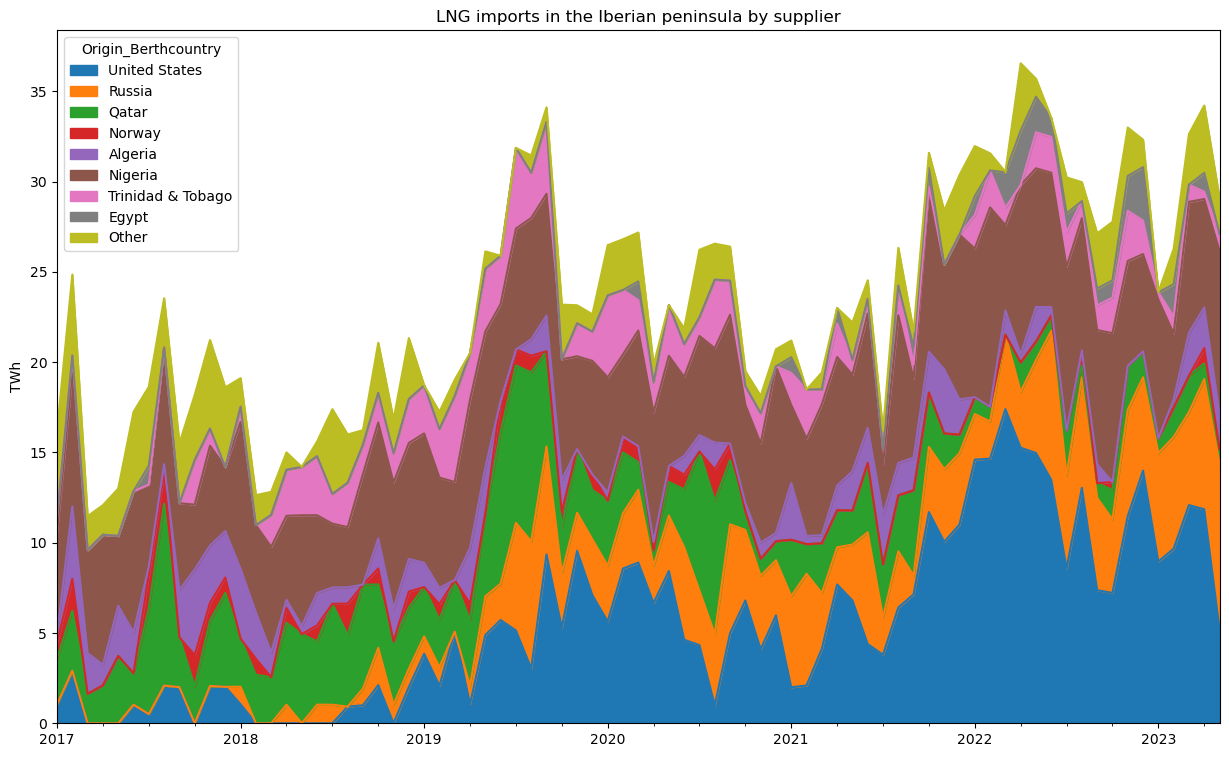

In [26]:
iberia_twh.plot(figsize=(15, 9),kind='area',ylabel='TWh', title='LNG imports in the Iberian peninsula by supplier')

In [27]:
iberia_twh.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\Iberian LNG by source in TWh.xlsx')

## Back to recurrent code

In [28]:
## Here we get 
dff = df_EU25.groupby(['Origin_Berthcountry']).sum(numeric_only=True)

In [29]:
dff_T = dff.T #drop(['nan_x','nan_y'])

In [30]:
dff_T.index = pd.to_datetime(dff_T.index)
dff_T = dff_T.sort_index()

### in M3m

In [31]:
dff_M3m = dff_T * converter

In [32]:
# Remove European re-exports
del dff_M3m['Belgium']
del dff_M3m['France']
del dff_M3m['Lithuania']
del dff_M3m['Netherlands']
del dff_M3m['Spain']

In [33]:
dff_EU = dff_M3m

In [34]:
dff_M3m.columns

Index(['Algeria', 'Angola', 'Australia', 'Brazil', 'Cameroon', 'China',
       'Dominican Republic', 'Egypt', 'Equatorial Guinea', 'Indonesia',
       'Jamaica', 'Malaysia', 'Mozambique', 'Nigeria', 'Norway', 'Oman',
       'Peru', 'Qatar', 'Russia', 'Trinidad & Tobago', 'United Arab Emirates',
       'United Kingdom', 'United States of America'],
      dtype='object', name='Origin_Berthcountry')

In [35]:
dff_M3m.tail()

Origin_Berthcountry,Algeria,Angola,Australia,Brazil,Cameroon,China,Dominican Republic,Egypt,Equatorial Guinea,Indonesia,...,Nigeria,Norway,Oman,Peru,Qatar,Russia,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America
2023-01-31,538.334369,278.806275,-0.0,-0.0,283.028288,-0.0,-0.0,252.272216,93.117524,-0.0,...,180.353398,543.201377,-0.000000,-0.0,1419.115139,968.092082,100.501647,-0.000000,-0.0,3386.157845
2023-02-28,522.892211,185.596339,-0.0,-0.0,99.135590,-0.0,-0.0,188.442867,-0.000000,-0.0,...,-0.000000,168.271374,-0.000000,-0.0,1243.696643,1356.133838,391.085051,79.186011,-0.0,3765.184761
2023-03-31,409.752813,185.616456,-0.0,-0.0,99.242461,-0.0,-0.0,137.843457,200.910254,-0.0,...,297.761330,451.886193,-0.000000,-0.0,993.764891,987.347632,-0.000000,-0.000000,-0.0,3964.219751
2023-04-30,785.845190,277.473537,-0.0,-0.0,98.815608,-0.0,-0.0,8.553412,-0.000000,-0.0,...,344.378242,355.011857,87.934305,-0.0,1648.441629,893.234326,177.968300,-0.000000,-0.0,5128.318617
2023-05-31,494.424424,185.915065,-0.0,-0.0,99.563072,-0.0,-0.0,296.091007,100.719788,-0.0,...,100.015072,358.934633,99.544842,-0.0,1578.188735,868.124159,49.875834,-0.000000,-0.0,5093.478205


In [36]:
include = ['Algeria','Norway','Nigeria','Qatar','Russia','Trinidad & Tobago','United States of America','Egypt']
exclude = list(set(dff_M3m.columns)-set(include))

In [37]:
## Define an "Other" category
dff_M3m['Other']= dff_M3m[exclude].sum(axis=1)

In [38]:
# dff_M3m['Argentina'].loc['2020':]+dff_M3m['Brazil'].loc['2020':]+dff_M3m['Peru'].loc['2020':]

In [39]:
dff_M3m['month'] = dff_M3m.index.strftime("%m")

In [40]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [41]:
dff_M3m

Origin_Berthcountry,Algeria,Angola,Australia,Brazil,Cameroon,China,Dominican Republic,Egypt,Equatorial Guinea,Indonesia,...,Oman,Peru,Qatar,Russia,Trinidad & Tobago,United Arab Emirates,United Kingdom,United States of America,Other,month
2017-01-31,367.528907,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,-0.000000,-0.0,...,-0.000000,-0.000000,854.036741,-0.000000,-0.000000,-0.000000,43.46549,-0.000000,43.465490,01
2017-02-28,409.997358,92.991794,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,-0.000000,-0.0,...,-0.000000,-0.000000,891.127720,-0.000000,-0.000000,-0.000000,-0.00000,44.068994,92.991794,02
2017-03-31,810.138740,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,83.256520,-0.0,...,-0.000000,-0.000000,1012.328925,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,83.256520,03
2017-04-30,378.980395,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,-0.000000,-0.0,...,-0.000000,88.139245,1337.394411,-0.000000,164.737732,-0.000000,-0.00000,-0.000000,88.139245,04
2017-05-31,564.558504,92.023673,-0.0,-0.0,-0.000000,-0.0,-0.0,139.439599,-0.000000,-0.0,...,-0.000000,88.234799,1394.703402,-0.000000,-0.000000,-0.000000,-0.00000,-0.000000,180.258472,05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-31,538.334369,278.806275,-0.0,-0.0,283.028288,-0.0,-0.0,252.272216,93.117524,-0.0,...,-0.000000,-0.000000,1419.115139,968.092082,100.501647,-0.000000,-0.00000,3386.157845,853.223897,01
2023-02-28,522.892211,185.596339,-0.0,-0.0,99.135590,-0.0,-0.0,188.442867,-0.000000,-0.0,...,-0.000000,-0.000000,1243.696643,1356.133838,391.085051,79.186011,-0.00000,3765.184761,463.053532,02
2023-03-31,409.752813,185.616456,-0.0,-0.0,99.242461,-0.0,-0.0,137.843457,200.910254,-0.0,...,-0.000000,-0.000000,993.764891,987.347632,-0.000000,-0.000000,-0.00000,3964.219751,485.769171,03
2023-04-30,785.845190,277.473537,-0.0,-0.0,98.815608,-0.0,-0.0,8.553412,-0.000000,-0.0,...,87.934305,-0.000000,1648.441629,893.234326,177.968300,-0.000000,-0.00000,5128.318617,563.365955,04


In [42]:
today = date.today()    

#### Get only 2019 onwards values

In [43]:
df_late =dff_M3m.loc['2019':]

In [44]:
df_late=df_late.rename(columns={'United States of America':'United States'})

In [45]:
df_late=df_late.drop('month',axis=1)
df_late = df_late[['Qatar','Algeria','Nigeria','Russia','Norway','United States','Trinidad & Tobago','Egypt','Other']]

In [48]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [49]:
# df_late.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\granular EU25 LNG imports.xlsx')

#### Aggregate to avoid problems with Bloomberg

In [50]:
dff_EU = dff_EU.loc['2019':]

In [51]:
dff_EU.columns

Index(['Algeria', 'Angola', 'Australia', 'Brazil', 'Cameroon', 'China',
       'Dominican Republic', 'Egypt', 'Equatorial Guinea', 'Indonesia',
       'Jamaica', 'Malaysia', 'Mozambique', 'Nigeria', 'Norway', 'Oman',
       'Peru', 'Qatar', 'Russia', 'Trinidad & Tobago', 'United Arab Emirates',
       'United Kingdom', 'United States of America', 'Other', 'month'],
      dtype='object', name='Origin_Berthcountry')

### In TWh

In [52]:
df_late.columns

Index(['Qatar', 'Algeria', 'Nigeria', 'Russia', 'Norway', 'United States',
       'Trinidad & Tobago', 'Egypt', 'Other'],
      dtype='object', name='Origin_Berthcountry')

In [53]:
df_twh = df_late/1000*10.3

In [54]:
df_twh = df_twh[['United States','Russia', 'Qatar',  'Norway', 'Algeria', 'Nigeria', 'Trinidad & Tobago', 'Egypt', 'Other']]

In [55]:
df_twh.to_excel(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2023-04 How the EU can phase out Russian LNG\Data\EU25 LNG imports.xlsx')

In [56]:
colors = {'United States':'#0080C7','Russia':'#E67425', 'Qatar':'#FFC000',  'Norway':'black', 'Algeria':'orange', 'Nigeria':'#2BB0CB', 'Trinidad & Tobago':'#0080C7', 'Egypt':'blue', 'Other':'#58A944'}

<Axes: title={'center': 'LNG imports in the EU by supplier'}, ylabel='TWh'>

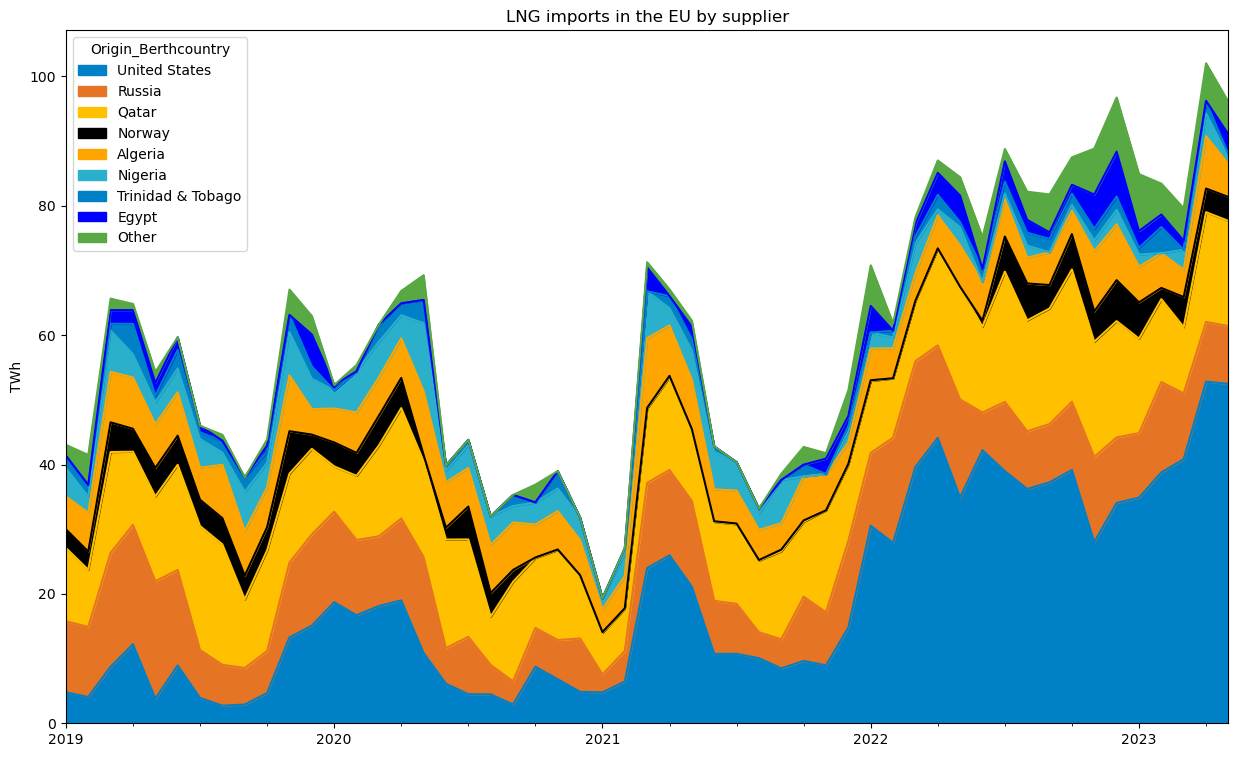

In [57]:
df_twh.plot(figsize=(15, 9),kind='area',ylabel='TWh', title='LNG imports in the EU by supplier',color=colors)